## Distributed-Lag Non-Linear Model (DLNM) 
This code uses different regression models to estimate temperature-attributable mortality for a given region, see [Gasparrini et al. (2015)](https://github.com/gasparrini/2015_gasparrini_Lancet_Rcodedata). This overall aim is to implement a [DLNM](https://cran.r-project.org/web/packages/dlnm/index.html) in Python for climate and health applications, and test to extensions/modifications of this method.

**This is currently in development and needs additional work.**

To-do list:
* Test functions against published DLNM example in R and published results from same dataset
* Develop methodology for minimum mortality temp and attributable deaths, currently quite basic
* Allow multiple regions and whole country to be modelled
* Increase efficiency of calculating uncertainty e.g. is there a better way of looping and bootstrapping
* Improve pre-processing e.g. renaming of dow features is clunky
* Improve prediction of temperature range - is using mean values for other predictors appropriate?
* General code review and error finding

____
Author: Euan Soutter [climate.health@ons.gov.uk]
27/02/24
____

### 1. Import packages

In [1]:
import pandas as pd
import numpy as np
import patsy
import xgboost as xgb
import re
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

from patsy import dmatrix
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor 
from sklearn.utils import resample
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error
from scipy.interpolate import BSpline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

### 2. Define cross-basis function

In [2]:
def cross_basis(temperatures, lag_days, knot_positions):
    
    """
    Generates the basis matrices for predictor and lags and combine into cross-basis. 
    Python implimentation of https://rdrr.io/cran/dlnm/man/crossbasis.html.
    Currently under development and has not been tested.

    Parameters
    ----------
    temperatures : array
        Array of temperatures.
    lag_days : int
        Number of lag days.
    knot_positions: list
        Where to place the knots in the spline function.

    Returns
    -------
    dataframe
        A Pandas dataframe representing the cross-basis. 
        Can be passed to regression formula or concatenated with other predictors.

    See Also
    --------
    https://rdrr.io/cran/dlnm/man/crossbasis.html

    Examples
    --------
    >>> cross_basis(df.temps, 21, [15, 75, 90])
    
    """
    
    dft = pd.DataFrame({'tmean': temperatures})

    # Create lagged versions of the temperature variable
    for i in range(1, lag_days + 1):
        
        dft[f'tmean_lag_{i}'] = np.roll(dft['tmean'], shift = i)
    
    dft.dropna(inplace = True)
    
    # Define the knots for the B-spline basis
    knots = np.quantile(dft['tmean'], knot_positions)
        
    # Create B-spline basis for the original temperature variable
    bspline_basis = dmatrix("bs(dft['tmean'], degree = 2, knots = knots)", 
                            {"dft['tmean']": dft['tmean'],
                             "knots":knots})
        
    lagknots = np.logspace(np.log10(1), np.log10(lag_days), 3, endpoint = False)

    # Create B-spline basis for lagged temperature variables
    lagged_bspline_bases = []
    
    for i in range(1, lag_days + 1):

        basis = dmatrix("bs(dft[f'tmean_lag_{i}'], knots = knots, degree = 2)", 
                        {"dft[f'tmean_lag_{i}']": dft[f'tmean_lag_{i}']})
        lagged_bspline_bases.append(basis)

    # Create the design matrix with the B-spline basis for both original and lagged variables    
    cb = np.hstack([bspline_basis] + lagged_bspline_bases) 
    cb = pd.DataFrame(cb)

    return cb

### 3. Prepare input data

In [3]:
# Load data and filter by a region
df = pd.read_csv('..\\tests\\testthat\\testdata\\regEngWalesPop.csv')
region = 'London'
df = df[df['regnames'] == region].reset_index()

# Create seasonal variable
df['seasonal'] = seasonal_decompose(df.tmean, 
                                    model = 'additive',
                                    period = 365).seasonal

df['date'] = pd.to_datetime(df.date)

# Generate cross-basis
cb = cross_basis(temperatures = df['tmean'], 
                 lag_days = 21, 
                 knot_positions = [0.1, 0.75, 0.9])

##################
# Create model

# Create formula for getting X matrix
formula = f'death ~ cb + seasonal + dewp + rh + dow'

# Create y and X matrices from the formula
y, X = patsy.dmatrices(formula, 
                       data = df, 
                       return_type = 'dataframe')

# Remove special characters from dow variables
X.rename(columns={'dow[T.Mon]': 'dow_mon', 
                 'dow[T.Sat]': 'dow_sat',
                 'dow[T.Sun]': 'dow_sun',
                 'dow[T.Thu]': 'dow_thu',
                 'dow[T.Tue]': 'dow_tue',
                 'dow[T.Wed]': 'dow_wed'}, inplace=True)

# Remove special characters from cross-basis variables for XGB Regressor
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X.columns.values]

# Drop intercept. This needs checked against sklearn functions and their intercept assignment.
X.drop(columns = 'Intercept', inplace = True)

### 4. Run regression simulations and plot results

Model 0
R² = 0.32
MAE = 18.0
Minimum mortality at: 27 °C
Model 1
R² = 0.34
MAE = 18.0
Minimum mortality at: 26 °C
Model 2
R² = 0.34
MAE = 17.0
Minimum mortality at: 23 °C
Model 3
R² = 0.31
MAE = 19.0
Minimum mortality at: 20 °C
Model 4
R² = 0.28
MAE = 18.0
Minimum mortality at: 26 °C
Model 5
R² = 0.41
MAE = 17.0
Minimum mortality at: 22 °C
Model 6
R² = 0.35
MAE = 17.0
Minimum mortality at: -4 °C
Model 7
R² = 0.35
MAE = 17.0
Minimum mortality at: 25 °C
Model 8
R² = 0.4
MAE = 17.0
Minimum mortality at: 21 °C
Model 9
R² = 0.35
MAE = 17.0
Minimum mortality at: 20 °C
Mean results = 
simulation           4.500000
r2                   0.350076
mae                 17.484066
min_temp            20.525253
attr_nu_all     128100.222555
attr_nu_cold    111513.067840
attr_nu_hot      16587.154715
attr_fr_all          0.151559
attr_fr_cold         0.131935
attr_fr_hot          0.019625
dtype: float64


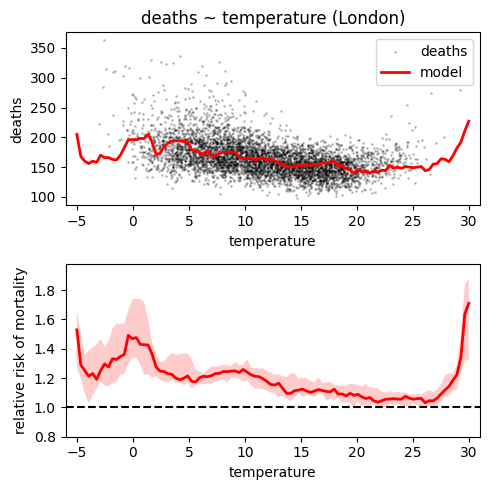

In [4]:
# Temperatures to predict over
temps = np.linspace(-5, 30, num = 100)

# Number of simulations for confidence intervals
number_of_simulations = 10

# Bootstraps for relative-risk confidence intervals
bootstraps = np.zeros((number_of_simulations, len(temps)))

# Model simulations
simulations = []

# Model metrics (r2 and mean absolute error)
r2s = []
maes = []

# Minimum mortality temperatures
min_temps = []

# Temperature-attributable deaths
an_alls = []
an_colds = []
an_hots = []

# Temperature-attributable fraction of deaths
af_alls = []
af_colds = []
af_hots = []

simulation = 0

# Run n simulations to calculate confidence intervals
while simulation < number_of_simulations:
    
    print(f'Model {simulation}')
    
    # Split in test and train datasets for model evaluation.
    X_train, X_test, y_train, y_test = train_test_split(X, np.array(y), test_size=0.2)
    
    # Fit a regression model. Comment out models you don't want to run. Be aware of parameters and hyper-parameters e.g. no of estimators in RF.
    model = RandomForestRegressor(n_estimators = 10).fit(X_train, y_train.ravel())
    # model = xgb.XGBRegressor().fit(X_train, y_train.ravel())
    # model = linear_model.PoissonRegressor(solver = 'newton-cholesky').fit(X_train, y_train.ravel())

    ##################
    
    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred, 0)
    
    # Evaulate model against tests
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2s.append(r2)
    maes.append(mae)
    
    print(f"R² = {np.round(r2, 2)}") 
    print(f"MAE = {np.round(mae, 0)}") 
    
    ##################
    
    # Predict over different temperatures
    cb = cross_basis(temperatures = temps,
                     lag_days = 21, 
                     knot_positions = [0.1, 0.75, 0.9]) 

    # Create formula for getting X and y matrices 
    formula = f'death ~ cb + seasonal + dewp + rh + dow_mon + dow_sat + dow_sun + dow_thu + dow_tue + dow_wed'

    # Create mean dataframe for predicting over temperatures. Is this appropriate?
    df_mean = pd.concat([pd.DataFrame(df.mean(numeric_only = True)).T] * len(temps), ignore_index = True)
    dow_mean = pd.DataFrame(X[['dow_mon', 'dow_sat', 'dow_sun', 'dow_thu', 'dow_tue', 'dow_wed']].mean(numeric_only = True)).T
    dow_mean = pd.concat([dow_mean] * len(temps), ignore_index = True)
    df_mean = pd.concat([dow_mean, df_mean], axis = 1)

    # Create y and X matrices from the formula 
    y_mean, X_mean = patsy.dmatrices(formula, 
                           data = df_mean, 
                           return_type = 'dataframe')
    
    regex = re.compile(r"\[|\]|<", re.IGNORECASE)
    X_mean.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_mean.columns.values]
    
    X_mean.drop(columns = 'Intercept', inplace = True)
    
    # Reorder columns as X for model predictions
    X_mean = X_mean[X.columns]

    ##################
    
    # Make predictions over different temperatures and calculate relative risk. Needs refinemenet.
    y_preds = model.predict(X_mean)
    y_preds_rounded = np.round(y_preds, 0)

    # Get minimum deaths as reference for RR
    reference = np.min(y_preds_rounded)
    rel_risk = y_preds_rounded/reference
    
    # Get minimum temperature associated with minimum deaths
    min_temp =  temps[np.argmin(y_preds_rounded)]
    min_temps.append(min_temp)
    
    print(f'Minimum mortality at: {round(min_temp)} °C')
    
    ##################
    # Get attributable deaths by assigning an RR to each temperature
    # and calculating the population attributable fraction (PAF)
    # from that RR. Needs refinement.
    
    rr = pd.DataFrame({'rr': rel_risk, 'temps': temps})
    
    def find_nearest_rr(temperatures):
        differences = np.abs(rr.temps - temperatures)
        index_nearest = differences.idxmin()
        return rr.loc[index_nearest, 'rr']
    
    df['RR'] = df['tmean'].apply(find_nearest_rr)
    df['paf'] = (df['RR'] - 1) / df['RR']
    df['an'] = df['death'] * df['paf']
    
    # Get hot and cold deaths by filtering above and below min_temp
    an_all = np.sum(df['an'])
    an_cold = np.sum(df.an[df.tmean < min_temp])
    an_hot = np.sum(df.an[df.tmean > min_temp])
    
    af_all = an_all/np.sum(df['death'])
    af_cold = an_cold/np.sum(df['death'])
    af_hot = an_hot/np.sum(df['death'])
    
    # Append results to lists at top of cell
    bootstraps[simulation] = rel_risk
          
    simulations.append(simulation)
    
    an_alls.append(an_all)
    an_colds.append(an_cold)
    an_hots.append(an_hot)
    
    af_alls.append(af_all)
    af_colds.append(af_cold)
    af_hots.append(af_hot)
       
    simulation += 1

##################

# Create results dataframe
results_df = pd.DataFrame({'simulation':simulations,
                           'r2': r2, 'mae': mae, 'min_temp': min_temps,
                           'attr_nu_all': an_alls, 'attr_nu_cold': an_colds, 'attr_nu_hot': an_hots,
                           'attr_fr_all': af_alls, 'attr_fr_cold': af_colds, 'attr_fr_hot': af_hots})

print(f'Mean results = \n{results_df.mean(numeric_only = True)}')

# Get confidence intervals from bootstraps 
lower = np.percentile(bootstraps, 2.5, axis = 0)
upper  = np.percentile(bootstraps, 97.5, axis = 0)
middle = np.percentile(bootstraps, 50, axis = 0)

# Plot results
fig, ax = plt.subplots(nrows = 2, figsize = (5, 5))

ax[0].scatter(df['tmean'], df['death'], 
              label='deaths', s = 1, color = 'k', alpha = 0.2)

ax[0].plot(temps, y_preds_rounded, 
           color='red', lw= 2,
           label = 'model')

ax[0].set(xlabel = 'temperature', 
          ylabel = 'deaths', 
          title = f'deaths ~ temperature ({region})',
          xlim = (temps.min() - 1, temps.max() + 1))

ax[0].legend()

ax[1].plot(temps, middle, 
           color='red', lw= 2, 
           label = 'relative risk of mortality')
ax[1].fill_between(temps, lower, upper, color='red', alpha= 0.2, edgecolor = None)

ax[1].set(xlabel = 'temperature', 
          ylabel = 'relative risk of mortality',
         xlim = (temps.min() - 1, temps.max() + 1),
         ylim = (0.8, max(upper) + 0.1))

ax[1].hlines(1, temps.min() - 1, temps.max() + 1, 
             linestyle = '--', color = 'k')

plt.tight_layout()
plt.show()

### i. Check seasonality

In [5]:
# Load data and filter by London
df_seas = pd.read_csv('..\\tests\\testthat\\testdata\\regEngWalesPop.csv')
df_seas = df_seas[df_seas['regnames'] == 'London'].reset_index()
df_seas.index = pd.DatetimeIndex(df_seas['date'])

# Seasonal period is a year
period = 365

# Decompose seasonal signal from temperatures
df_seas['seasonal'] = seasonal_decompose(df_seas.tmean, 
                                    model = 'additive',
                                    period = period).seasonal

df_seas['trend'] = seasonal_decompose(df_seas.tmean, 
                                    model = 'additive',
                                    period = period).trend

df_seas['resid'] = seasonal_decompose(df_seas.tmean, 
                                    model = 'additive',
                                    period = period).resid

# Plot
fig, ax = plt.subplots(nrows = 4, figsize = (6, 6))

ax[0].plot(df_seas.tmean, color = 'k', lw = 1, label = 'tmean')
ax[0].plot(df_seas.seasonal, color = 'grey', lw = 1, label = 'seasonal')
ax[0].legend()


ax[1].plot(df_seas.trend, color = 'grey', lw = 1, label = 'trend (minus seasons and noise)')
ax[1].legend()

ax[2].plot(df_seas.resid, 'o', color = 'grey', markersize = 1, label = 'seasonal residuals')
ax[2].legend()

sns.kdeplot(df_seas.resid, ax = ax[3], color = 'grey')

plt.tight_layout()

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/soutte/code/data_explorer/data/regEngWalesPop.csv'